### Asian Hornet

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('Data\Vespa velutina.csv')
df_habitats = pd.read_csv('Data\habitats_cbs_2022.csv')

<>:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:2: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
<>:2: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\sidne\AppData\Local\Temp\ipykernel_24736\1143912552.py:1: SyntaxWarning: "\V" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\V"? A raw string is also an option.
  df = pd.read_csv('Data\Vespa velutina.csv')
C:\Users\sidne\AppData\Local\Temp\ipykernel_24736\1143912552.py:2: SyntaxWarning: "\h" is an invalid escape sequence. Such seque

---

## 1. Business Understanding

#### **Situation Description**

The Vespa Velutina otherwise known as the Asian Hornet is an invasive species of insect present in the Netherlands. 

#### **Business Objective(s)**

#### **Data Mining Goal(s)**

#### **Success Criteria**


---

## 2. Data Understanding

**Data exploration**

In [3]:
df = df.iloc[:-30]

print(df)
df['eventDate'] = pd.to_datetime(df['eventDate'])
df['year'] = df['eventDate'].dt.year
df['month'] = df['eventDate'].dt.month

print(f"Dataset vorm: {df.shape}")
print(f"\nEerste rijen:")
print(df.head())
print(f"\nGegevenstypen:")
print(df.dtypes)
print(f"\nBasisstatistieken:")
print(df.describe())

          decimalLatitude  decimalLongitude   eventDate  total_observations  \
0                   50.75              5.65  2010-01-01                 0.0   
1                   50.75              5.65  2010-01-02                26.0   
2                   50.75              5.65  2010-01-03                 3.0   
3                   50.75              5.65  2010-01-04                 0.0   
4                   50.75              5.65  2010-01-05                 0.0   
...                   ...               ...         ...                 ...   
12558751            53.50              6.55  2025-12-27                 0.0   
12558752            53.50              6.55  2025-12-28                 0.0   
12558753            53.50              6.55  2025-12-29                 0.0   
12558754            53.50              6.55  2025-12-30                 0.0   
12558755            53.50              6.55  2025-12-31                 0.0   

          speciesgroup_observations Vespa velutina 

**Visualizations and patterns**

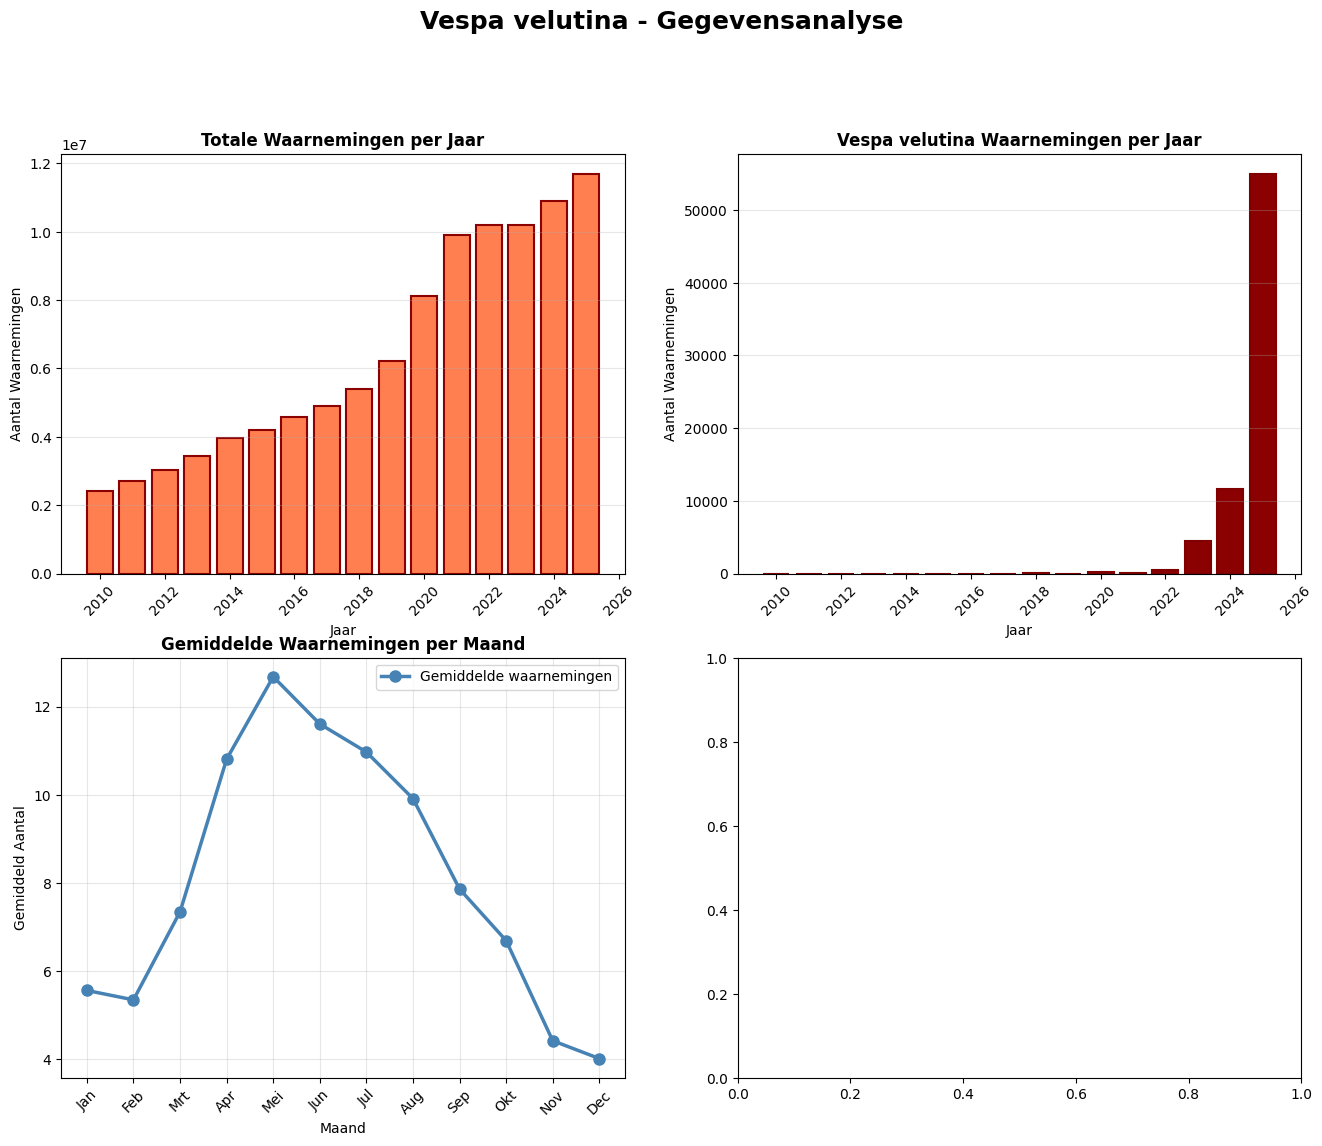

In [4]:


# Maak een figure met meerdere subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Vespa velutina - Gegevensanalyse', fontsize=18, fontweight='bold', y=1.00)

# 1. Totale waarnemingen per jaar
yearly_data = df.groupby('year')['total_observations'].sum()
axes[0, 0].bar(yearly_data.index, yearly_data.values, color='coral', edgecolor='darkred', linewidth=1.5)
axes[0, 0].set_title('Totale Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 0].set_xlabel('Jaar')
axes[0, 0].set_ylabel('Aantal Waarnemingen')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Vespa velutina waarnemingen per jaar
vespa_yearly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['year']).sum()
axes[0, 1].bar(vespa_yearly.index, vespa_yearly.values, color='darkred', edgecolor='maroon', linewidth=1.5)
axes[0, 1].set_title('Vespa velutina Waarnemingen per Jaar', fontweight='bold', fontsize=12)
axes[0, 1].set_xlabel('Jaar')
axes[0, 1].set_ylabel('Aantal Waarnemingen')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Gemiddelde waarnemingen per maand
monthly_avg = df.groupby('month')['total_observations'].mean()
vespa_monthly = pd.to_numeric(df['Vespa velutina'], errors='coerce').fillna(0).groupby(df['month']).sum()
month_names = ['Jan', 'Feb', 'Mrt', 'Apr', 'Mei', 'Jun', 'Jul', 'Aug', 'Sep', 'Okt', 'Nov', 'Dec']
axes[1, 0].plot(monthly_avg.index, monthly_avg.values, marker='o', linewidth=2.5, markersize=8, 
                color='steelblue', label='Gemiddelde waarnemingen')
axes[1, 0].set_xticks(range(1, 13))
axes[1, 0].set_xticklabels(month_names, rotation=45)
axes[1, 0].set_title('Gemiddelde Waarnemingen per Maand', fontweight='bold', fontsize=12)
axes[1, 0].set_xlabel('Maand')
axes[1, 0].set_ylabel('Gemiddeld Aantal')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].legend()


## Data Insights and Data Quality

### Data Insights

### Data Quality Issues

---

## 3. Data Preparation

**Cleaning and preprocessing**

## Data Cleaning and Preprocessing

In [5]:
df['Vespa velutina'].value_counts()

Vespa velutina
0     12404637
0       106914
1        33020
2         8791
3         2980
4         1239
5          540
6          274
7          151
8           86
9           34
10          30
11          16
12          11
13          10
14           6
15           4
19           3
16           3
20           2
32           1
22           1
17           1
1            1
3            1
Name: count, dtype: int64